# **Project Name**    - Gender Classification Model

**Project Type** - Classification

**Contribution** - Individual

**Team Member 1** - Shyam Sundar Paul

# **Project Summary -**

This project develops a gender classification model using structured user information such as company, age, and encoded name embeddings. The objective is to build a reliable classifier that predicts gender while following a structured machine learning workflow, including data preprocessing, feature engineering, model comparison, and evaluation.

The notebook explores several classification methods, compares their performance, and saves the best-performing model for deployment. It also includes a reproducible path setup so the project can run correctly in different workspace layouts.

# **GitHub Link -**

[Gender Classification Module](https://github.com/Shyam2143/Voyage-Analytics-Integrating-MLOps-in-Travel.git)

# **Problem Statement**


Deploy a classification model to categorize a user's gender based on available profile information and name-based features.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

# ***Let's Begin !***

## 1. Know Your Data

### Import Libraries


In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import random
import matplotlib.pyplot as plt



import warnings
warnings.filterwarnings("ignore")


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,classification_report, precision_recall_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


### Dataset Loading


In [2]:
# Load Dataset
from pathlib import Path

PROJECT_ROOT = next(
    parent
    for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "artifacts" / "models").is_dir()
)

DATA_DIR = PROJECT_ROOT / "data"
if not DATA_DIR.exists():
    DATA_DIR = PROJECT_ROOT.parent / "DATA"

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset directory not found for project root: {PROJECT_ROOT}")

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
user_df = pd.read_csv(DATA_DIR / "users.csv")

In [3]:
user_df.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


## 2. Understanding Your Variables

In [4]:
user_df.isnull().sum()

code       0
company    0
name       0
gender     0
age        0
dtype: int64

In [5]:
user_df.duplicated().sum()

np.int64(0)

1. gender feature is our dependent feature,we will encode the categorical values in this feature i.e male and female using label encoder,to fetch it into our classification model for training.1 denotes male and 0 denotes female.

2. Similarly we will encode values in company features using label encoder.

3. On name feature we will use NLP model such as sentence transformer and use pca technique,before fetching it for buliding the classification model.



In [6]:
user_df.nunique()

code       1340
company       5
name       1338
gender        3
age          45
dtype: int64

In [7]:
# Summary of categorical features
user_df.describe(include=object)

,company,name,gender
count,1340,1340,1340
unique,5,1338,3
top,4You,Charlotte Johnson,male
freq,453,2,452


As we see, the target variable has three categories in the raw dataset; therefore, we filter to the relevant binary labels before modeling. This keeps the classification task consistent with the project goal and avoids noisy labels that could affect the training process.

In [8]:
user_df['gender'].value_counts()

gender
male      452
female    448
none      440
Name: count, dtype: int64

In [9]:
#filtering records based on relavent categories in the target variable
user_df1=user_df[(user_df['gender']=='male') | (user_df['gender']=='female') ]

In [10]:
user_df.shape

(1340, 5)

In [11]:
user_df1

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44
...,...,...,...,...,...
1335,1335,Umbrella LTDA,Albert Garroutte,male,23
1336,1336,Umbrella LTDA,Kim Shores,female,40
1337,1337,Umbrella LTDA,James Gimenez,male,28
1338,1338,Umbrella LTDA,Viola Agosta,female,52


In [12]:
user_df1.shape

(900, 5)

In [13]:
# Encode userCode and company to numeric values
label_encoder = LabelEncoder()

user_df1['company_encoded'] = label_encoder.fit_transform(user_df1['company'])
user_df1['gender_encoded'] = label_encoder.fit_transform(user_df1['gender'])

user_df1.head()

,code,company,name,gender,age,company_encoded,gender_encoded
0,0,4You,Roy Braun,male,21,0,1
1,1,4You,Joseph Holsten,male,37,0,1
2,2,4You,Wilma Mcinnis,female,48,0,0
3,3,4You,Paula Daniel,female,23,0,0
4,4,4You,Patricia Carson,female,44,0,0


In [14]:
from sentence_transformers import SentenceTransformer

# Initialize the SentenceTransformer model
model = SentenceTransformer('flax-sentence-embeddings/all_datasets_v4_MiniLM-L6')

# Encode text-based columns and create embeddings
text_columns = ['name']

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 38204.22it/s]


In [15]:
for column in text_columns:
    user_df1[column + '_embedding'] = user_df1[column].apply( lambda text: model.encode(text))

In [16]:
# Concatenate the embeddings into a single feature vector
text_embeddings = user_df1[text_columns].values.tolist()

In [17]:
#  Apply PCA separately to each text embedding column
n_components = 23  # Adjust the number of components as needed
pca = PCA(n_components=n_components)
text_columns = ['name']
# Create an empty array to store the PCA-transformed embeddings
text_embeddings_pca = np.empty((len(user_df1), n_components * len(text_columns)))

In [18]:
for i, column in enumerate(text_columns):
    embeddings = user_df1[column + '_embedding'].values.tolist()
    embeddings_pca = pca.fit_transform(embeddings)
    text_embeddings_pca[:, i * n_components:(i + 1) * n_components] = embeddings_pca

numerical_features=['code','company_encoded','age']

X_numerical = user_df1[numerical_features].values

In [19]:
# Combine PCA-transformed text embeddings and numerical features
X = np.hstack((text_embeddings_pca, X_numerical))
# Target variable
y = user_df1['gender_encoded']

In [20]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Logistic Regression


In [21]:
# Initialize a Logistic Regression Classifier
lr_classifier = LogisticRegression(random_state=42)

# Fit the model to the training data
lr_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred_lr = lr_classifier.predict(X_test)


# Calculate and print accuracy
accuracy = lr_classifier.score(X_test, y_test)
print("Accuracy:", round(accuracy,2))

# Generate a classification report
report = classification_report(y_test, y_pred_lr)
print("\nClassification Report:\n", report)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)


Accuracy: 0.96

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95        77
           1       0.95      0.98      0.97       103

    accuracy                           0.96       180
   macro avg       0.96      0.96      0.96       180
weighted avg       0.96      0.96      0.96       180



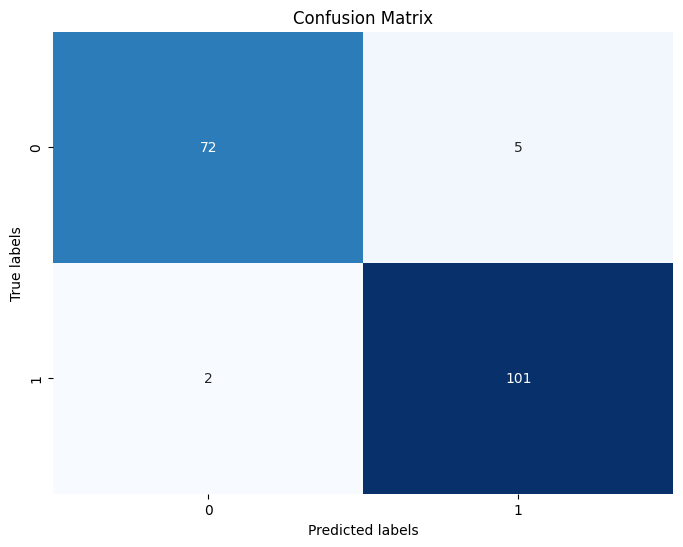

In [22]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model on the training set
lr_classifier.fit(X_train, y_train)

# Predictions on training and validation sets
y_train_pred = lr_classifier.predict(X_train)
y_val_pred = lr_classifier.predict(X_val)


# Calculate accuracy on training and validation sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

Training Accuracy: 0.9722222222222222
Validation Accuracy: 0.9666666666666667


In [24]:
# Check if overfitting
if train_accuracy > val_accuracy:
    print("The model is overfitting.")
else:
    print("The model is not overfitting.")


The model is overfitting.


## Decision Tree Classifier


In [25]:
# Initialize a decision tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)


# Fit the model to the training data
dt_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred_dt = dt_classifier.predict(X_test)

# Calculate and print accuracy
accuracy = dt_classifier.score(X_test, y_test)
print("Accuracy:", accuracy)

# Generate a classification report
report = classification_report(y_test, y_pred_dt)
print("\nClassification Report:\n", report)

cm = confusion_matrix(y_test, y_pred_dt)

Accuracy: 0.2833333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.14      0.13      0.13        77
           1       0.38      0.40      0.39       103

    accuracy                           0.28       180
   macro avg       0.26      0.26      0.26       180
weighted avg       0.28      0.28      0.28       180



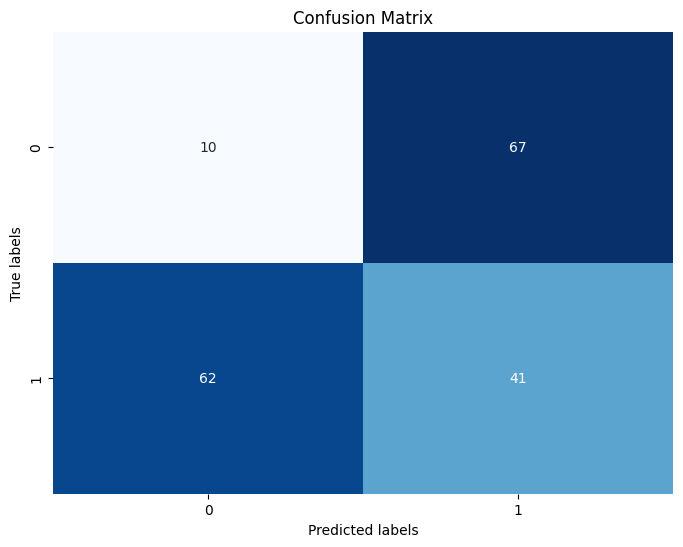

In [26]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


In [27]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model on the training set
dt_classifier.fit(X_train, y_train)

# Predictions on training and validation sets
y_train_pred = dt_classifier.predict(X_train)
y_val_pred = dt_classifier.predict(X_val)

# Calculate accuracy on training and validation sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)


Training Accuracy: 1.0
Validation Accuracy: 0.9222222222222223


## Random Forest Classifier


In [28]:
# Initialize a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_classifier.predict(X_test)

In [29]:
# Calculate and print accuracy
accuracy = rf_classifier.score(X_test, y_test)
print("Accuracy:", accuracy)

# Generate a classification report
report = classification_report(y_test, y_pred_rf)
print("\nClassification Report:\n", report)

cm = confusion_matrix(y_test, y_pred_rf)


Accuracy: 0.95

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94        77
           1       0.94      0.98      0.96       103

    accuracy                           0.95       180
   macro avg       0.95      0.94      0.95       180
weighted avg       0.95      0.95      0.95       180



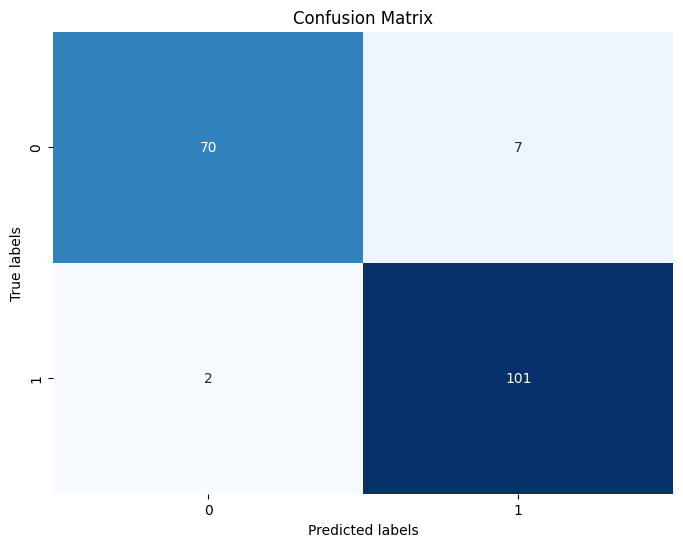

In [30]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [31]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model on the training set
rf_classifier.fit(X_train, y_train)

# Predictions on training and validation sets
y_train_pred = rf_classifier.predict(X_train)
y_val_pred = rf_classifier.predict(X_val)

# Calculate accuracy on training and validation sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

Training Accuracy: 1.0
Validation Accuracy: 0.9833333333333333


In [32]:
# Check if overfitting
if train_accuracy > val_accuracy:
    print("The model is overfitting.")
else:
    print("The model is not overfitting.")


The model is overfitting.


## Gradient Boosting Classifier


In [33]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize a Random Forest Classifier
gb_classifier = GradientBoostingClassifier(n_estimators=100, random_state=42)


In [34]:
# Fit the model to the training data
gb_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred_gb = gb_classifier.predict(X_test)

# Calculate and print accuracy
accuracy = gb_classifier.score(X_test, y_test)
print("Accuracy:", accuracy)

# Generate a classification report
report = classification_report(y_test, y_pred_gb)
print("\nClassification Report:\n", report)

cm = confusion_matrix(y_test, y_pred_gb)

Accuracy: 0.9722222222222222

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97        77
           1       0.97      0.98      0.98       103

    accuracy                           0.97       180
   macro avg       0.97      0.97      0.97       180
weighted avg       0.97      0.97      0.97       180



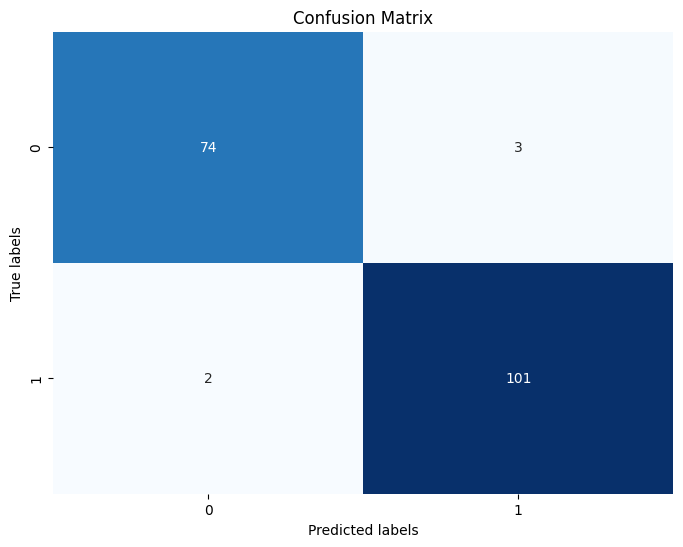

In [35]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [36]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model on the training set
gb_classifier.fit(X_train, y_train)

# Predictions on training and validation sets
y_train_pred = gb_classifier.predict(X_train)
y_val_pred = gb_classifier.predict(X_val)

# Calculate accuracy on training and validation sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

Training Accuracy: 1.0
Validation Accuracy: 0.9722222222222222


In [37]:
# Check if overfitting
if train_accuracy > val_accuracy:
    print("The model is overfitting.")
else:
    print("The model is not overfitting.")

The model is overfitting.


## ROC-AUC Curve

In [38]:
def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Fit the model to the training data
    model.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Evaluate the model
    report = classification_report(y_test, y_pred)

     # Print accuracy and classification report
    #print(f"\nAccuracy for {model_name}: {accuracy:.2f}")
    #print(f"Classification Report for {model_name}:\n{report}")

    # Return accuracy and classification report
    return report

In [39]:
# Initialize models
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
gradient_boosting = GradientBoostingClassifier(n_estimators=100, random_state=42)
decision_tree = DecisionTreeClassifier(random_state=42)
logistic_regression = LogisticRegression(random_state=42)

In [40]:
# Create a dictionary to store the classification reports
model_reports = {}

# Train and evaluate each model
print("Now.... RF")
model_reports['Random Forest'] = train_and_evaluate_model(random_forest, X_train, y_train, X_test, y_test, 'Random Forest')
print("Now.... GB")
model_reports['Gradient Boosting'] = train_and_evaluate_model(gradient_boosting, X_train, y_train, X_test, y_test, 'Gradient Boosting')
print("Now.... DT")
model_reports['Decision Tree'] = train_and_evaluate_model(decision_tree, X_train, y_train, X_test, y_test, 'Decision Tree')
print("Now.... Logistic Regression")
model_reports['Logistic Regression'] = train_and_evaluate_model(logistic_regression, X_train, y_train, X_test, y_test, 'Logistic Regression')

# Save the classification reports to a CSV file
reports_df = pd.DataFrame.from_dict(model_reports, orient='index', columns=['Classification Report'])
reports_df.to_csv(REPORTS_DIR / 'classification_reports.csv')

Now.... RF
Now.... GB
Now.... DT
Now.... Logistic Regression


In [41]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [42]:
# Assuming y_test and y_pred are lists or arrays containing true labels and predicted probabilities for each model

# Initialize lists to store fpr, tpr, and roc_auc for each model
fpr_list = []
tpr_list = []
roc_auc_list = []

# Compute ROC curve and ROC AUC for each model
for y_pred in [y_pred_lr,y_pred_dt,y_pred_rf,y_pred_gb]:
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    roc_auc_list.append(roc_auc)

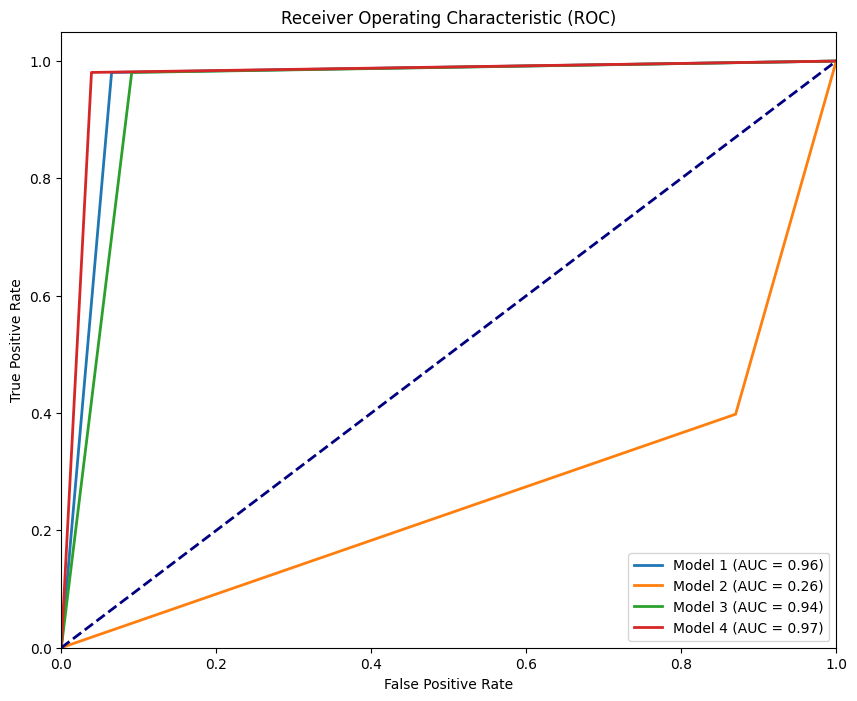

In [43]:
# Plot ROC curves for each model
plt.figure(figsize=(10, 8))
for i, roc_auc in enumerate(roc_auc_list):
    plt.plot(fpr_list[i], tpr_list[i], lw=2, label=f'Model {i+1} (AUC = {roc_auc:0.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

## Benchmark Model Selection and Hyperparameter Tuning

Logistic Regression is our Benchmark model

In [44]:
from sklearn.model_selection import GridSearchCV


# Define hyperparameters to tune
param_grid = {
    'penalty': ['l1', 'l2'],  # Regularization penalty
    'C': [0.01, 0.1, 1, 4, 100],  # Inverse of regularization strength
    'solver': ['liblinear', 'saga']  # Algorithm to use in the optimization problem
}

# Initialize a Logistic Regression Classifier
lr_classifier = LogisticRegression(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(lr_classifier, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters found
print("Best Hyperparameters:", grid_search.best_params_)

# Use the best model found by GridSearchCV
best_lr_classifier = grid_search.best_estimator_

# Make predictions on the test data using the best model
y_pred_lr_tuned = best_lr_classifier.predict(X_test)

# Calculate and print accuracy using the best model
accuracy_tuned = best_lr_classifier.score(X_test, y_test)
print("Tuned Model Accuracy:", accuracy_tuned)

Best Hyperparameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Tuned Model Accuracy: 0.9611111111111111



Tuned Model Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.92      0.95        77
           1       0.94      0.99      0.97       103

    accuracy                           0.96       180
   macro avg       0.97      0.96      0.96       180
weighted avg       0.96      0.96      0.96       180



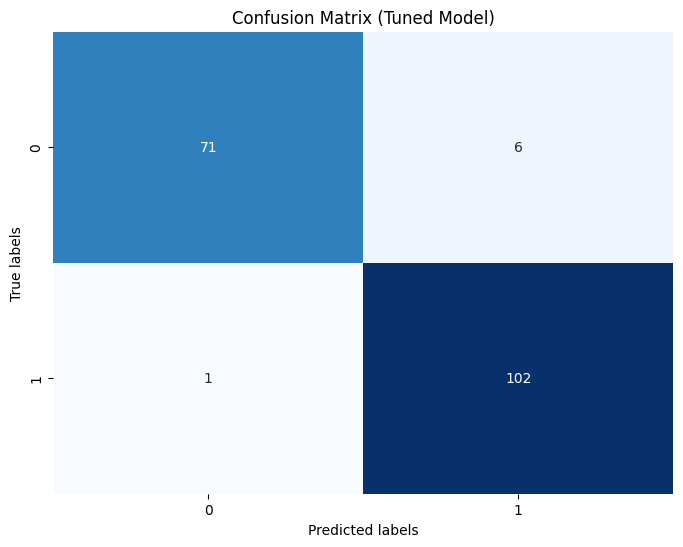

In [45]:
# Generate a classification report using the tuned model
report_tuned = classification_report(y_test, y_pred_lr_tuned)
print("\nTuned Model Classification Report:\n", report_tuned)

# Calculate confusion matrix using the tuned model
cm_tuned = confusion_matrix(y_test, y_pred_lr_tuned)

# Plot confusion matrix using the tuned model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Tuned Model)')
plt.show()

In [46]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model on the training set
best_lr_classifier.fit(X_train, y_train)

# Predictions on training and validation sets
y_train_pred = best_lr_classifier.predict(X_train)
y_val_pred = best_lr_classifier.predict(X_val)

# Calculate accuracy on training and validation sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

Training Accuracy: 0.9666666666666667
Validation Accuracy: 0.9611111111111111


In [47]:
# Check if overfitting
if (train_accuracy - val_accuracy) > 0.1:
    print("The model is overfitting.")
else:
    print("The model is not overfitting.")


The model is not overfitting.


## Save the Model

In [48]:
import pickle

# Pickle the tuned logistic regression model
with (ARTIFACTS_DIR / 'tuned_logistic_regression_model.pkl').open('wb') as file:
    pickle.dump(best_lr_classifier, file)

In [49]:
import joblib 

# Save the fitted scaler
joblib.dump(scaler, ARTIFACTS_DIR / 'scaler.pkl')
print("Scaler saved successfully as scaler.pkl")

Scaler saved successfully as scaler.pkl


In [50]:
# Save the fitted PCA model
joblib.dump(pca, ARTIFACTS_DIR / 'pca.pkl')
print("PCA model saved successfully as pca.pkl")

PCA model saved successfully as pca.pkl


# **Conclusion**

Overall, this project demonstrates that combining structured profile information with name-based embeddings can create a practical gender classification model. The workflow included data cleaning, target filtering, feature engineering, model comparison, hyperparameter tuning, and artifact saving, which are essential steps in a real-world machine learning pipeline. The notebook also highlights the importance of choosing a reliable dataset path and maintaining reproducible project structure for deployment-ready work. By evaluating multiple classifiers and preparing the final model for reuse, this project provides a solid foundation for future improvements such as expanded feature sets, additional algorithms, and real-time deployment.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***